# Sección 4 (parte B): Word2Vec de gensim y GloVe preentrenado

Este notebook obtiene los otros dos conjuntos de embeddings que se comparan con el SGNS propio:

1. **Word2Vec de gensim** (skip-gram con negative sampling) entrenado sobre *exactamente* el mismo corpus y el mismo vocabulario que usa el SGNS propio (los artefactos de `preprocesamiento.ipynb` en `cache/`). Se guardan **dos corridas por separado**:
   - `gensim_d300_e3`: **referencia del SGNS ganador** (`d300_c100`): 300 dimensiones, 3 epochs, ventana 5, 5 negativos, submuestreo `t = 1e-4`.
   - `gensim_d100_e10`: la corrida anterior (100 dimensiones, 10 epochs), conservada para comparar a igual dimensión con GloVe-100 y con el SGNS de 100 dimensiones.
2. **GloVe preentrenado** (`glove-wiki-gigaword-100`), usado tal cual, sin entrenamiento adicional, con la información de entrenamiento y hardware que reportan sus autores.

Todo se evalúa con el módulo reutilizable `evaluation.py` (analogías de `questions-words.txt` con 3CosAdd/3CosMul y correlación de Spearman en WordSim-353). **SimLex-999 no se toca aquí**: el enunciado lo reserva para la evaluación final.

El registro por epoch (pérdida, accuracy de analogías semánticas/sintácticas/total, Spearman en WordSim-353, 5 vecinos de las palabras de control, tiempo y memoria) es el mismo `EpochLogger` que usa el SGNS propio, de modo que las curvas son comparables.

In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors

import utils as U
import evaluation as EV
import corpus_cache as CC

np.seterr(all="ignore")          # avisos espurios de matmul en Apple Silicon (ver evaluation._sims)
SEED = 42
CACHE = Path("cache")
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
pd.options.display.float_format = "{:.4f}".format
HARDWARE = EV.hardware_info()
print(HARDWARE)

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


{'platform': 'macOS-26.6.2-arm64-arm-64bit', 'machine': 'arm64', 'cpu_count': 10, 'cpu': 'Apple M5', 'ram_gb': 16, 'gpu': 'ninguna (CPU)'}


## 4.B.1 Mismo corpus y mismo vocabulario que el SGNS propio

Se reutiliza el corpus ya normalizado, tokenizado y codificado en la sección 2 (`cache/train_ids.npy`, `train_offsets.npy`, `vocab.json`): un prefijo de WikiText-103 de ~30M tokens, `min_count = 5`, sin tokens desconocidos (se eliminan, como hace gensim). Cada párrafo es una "oración", así que ni la ventana de gensim ni la del SGNS propio cruzan límites de párrafo.

Para que el vocabulario sea idéntico no se deja que gensim lo reconstruya: se le entrega el vocabulario ya filtrado con sus frecuencias (`build_vocab_from_freq`) y `min_count=1`. Así gensim no descarta ni agrega ninguna palabra y las frecuencias que usa para el submuestreo y para la distribución de negativos son las mismas del SGNS propio.

In [2]:
itos, counts, ids, offsets, meta = CC.load_corpus_cache(CACHE)

words = np.array(itos, dtype=object)
sentences = [words[ids[offsets[p]:offsets[p + 1]]].tolist() for p in range(len(offsets) - 1)]
freq = {w: int(c) for w, c in zip(itos[2:], counts[2:])}      # sin <pad> ni <unk>

print(f"Párrafos (oraciones): {len(sentences):,} | tokens: {len(ids):,}")
print(f"Vocabulario sin <pad>/<unk>: {len(freq):,} palabras | min_count del preprocesamiento: {meta['min_count']}")

Corpus: 29,552,958 tokens en 303,140 párrafos | vocabulario: 109,646 (incluye <pad>, <unk>)


Párrafos (oraciones): 303,140 | tokens: 29,552,958
Vocabulario sin <pad>/<unk>: 109,644 palabras | min_count del preprocesamiento: 5


## 4.B.2 Word2Vec de gensim (skip-gram + negative sampling)

Los hiperparámetros equivalentes a los del SGNS propio se definen en `GENSIM_RUNS`. La correspondencia con los parámetros del SGNS desde cero es:

| SGNS propio | gensim `Word2Vec` | Nota |
|---|---|---|
| dimensión del embedding | `vector_size` | |
| tamaño de ventana | `window` | gensim usa ventana dinámica (tamaño efectivo ~ U{1..w}), igual que `dynamic=True` en `utils.py` |
| número de negativos | `negative` | distribución unigrama^0.75, como el SGNS |
| umbral de submuestreo `t` | `sample` | misma fórmula que `keep_probs(..., formula="gensim")` |
| epochs | `epochs` | |
| learning rate | `alpha` → `min_alpha` | decaimiento lineal por palabra procesada (el SGNS propio usa SparseAdam con decaimiento lineal; no son idénticos) |
| `min_count` | `min_count=1` + vocabulario prefiltrado | el filtro `min_count=5` ya se aplicó en la sección 2 |
| `sg=1` | skip-gram (no CBOW) | |

Con varios hilos gensim no es exactamente determinista (el orden en que los hilos toman lotes cambia), así que dos corridas con la misma semilla dan resultados muy parecidos pero no idénticos.

In [3]:
BASE = dict(window=5, negative=5, sample=1e-4, alpha=0.025, min_alpha=1e-4, min_count=1, sg=1, seed=SEED)
GENSIM_RUNS = {
    # referencia del SGNS ganador (d300_c100): mismo corpus, vocabulario, ventana, negativos y submuestreo
    "gensim_d300_e3": dict(label="gensim (d300, 3 ep)", cfg=dict(vector_size=300, epochs=3, **BASE)),
    # corrida anterior, conservada aparte: igual dimensión que GloVe-100
    "gensim_d100_e10": dict(label="gensim (d100, 10 ep)", cfg=dict(vector_size=100, epochs=10, **BASE)),
}


def train_gensim(run, cfg, label):
    model = Word2Vec(workers=os.cpu_count(), **cfg)
    model.build_vocab_from_freq(freq, corpus_count=len(sentences))
    # Pérdida SGNS por par sobre una muestra fija de pares/negativos (misma sonda que puede usar el SGNS propio)
    probe = EV.SGNSLossProbe(ids, offsets, counts, window=cfg["window"], k=cfg["negative"], seed=SEED)
    rows = np.array([model.wv.key_to_index.get(w, -1) for w in itos])          # id del corpus -> fila de gensim
    logger = EV.EpochLogger(name=label, config=cfg, track_gpu=False)           # CPU: sin memoria de GPU
    with EV.mute_stderr():                                                      # ver docstring de mute_stderr
        model.train(sentences, total_examples=len(sentences), epochs=cfg["epochs"],
                    callbacks=[EV.GensimEpochCallback(logger, probe, rows)])
    return model, logger


spaces, histories, neighbors_hist, cached = {}, {}, {}, {}
for run, spec in GENSIM_RUNS.items():
    cfg, label = spec["cfg"], spec["label"]
    kv_path, log_path = CACHE / f"{run}.kv", RESULTS / f"{run}.json"
    # Si ya hay un entrenamiento guardado con la misma configuración, se reutiliza (no se reentrena).
    cached[run] = log_path.exists() and kv_path.exists() and json.load(open(log_path))["summary"]["config"] == cfg
    if cached[run]:
        saved = json.load(open(log_path))
        histories[run], neighbors_hist[run] = pd.DataFrame(saved["history"]), saved["neighbors"]
        spaces[run] = EV.load_kv(kv_path, name=label)
        print(f"{run}: reutilizando el entrenamiento guardado en {kv_path}")
    else:
        model, logger = train_gensim(run, cfg, label)
        logger.save(log_path)
        model.wv.save(str(kv_path))
        histories[run] = logger.df
        neighbors_hist[run] = {str(e): v for e, v in logger.neighbors_by_epoch.items()}
        spaces[run] = EV.EmbeddingSpace.from_keyed_vectors(model.wv, name=label)
    # Metadatos de procedencia: qué modelo y configuración produjo este resultado
    saved = json.load(open(log_path))
    saved["meta"] = dict(run=run, model="Word2Vec de gensim (skip-gram, negative sampling)", label=label, config=cfg,
                         corpus=dict(tokens=int(len(ids)), paragraphs=len(sentences), vocab=len(freq),
                                     source="WikiText-103 (prefijo de ~30M tokens), cache/ de preprocesamiento.ipynb"),
                         hardware=HARDWARE, workers=os.cpu_count(), vectors=str(kv_path),
                         note="corrida anterior conservada aparte" if run == "gensim_d100_e10" else "referencia gensim del SGNS ganador d300_c100")
    json.dump(saved, open(log_path, "w"), indent=1, default=float)
    s = saved["summary"]
    print(f"{label}: {s['total_train_s']:.0f}s de entrenamiento ({s['total_train_s'] / cfg['epochs']:.0f}s por epoch) | "
          f"vocabulario {len(spaces[run]):,} | dimensión {spaces[run].dim} | GPU: n/a (CPU, {HARDWARE.get('cpu')})")

[gensim (d300, 3 ep)] epoch  1 | loss 2.8654 | analogías sem 0.088 sin 0.195 total 0.163 | WS353 0.521 | 23s (+1.9s eval)


[gensim (d300, 3 ep)] epoch  2 | loss 2.7233 | analogías sem 0.181 sin 0.367 total 0.311 | WS353 0.620 | 24s (+2.5s eval)


[gensim (d300, 3 ep)] epoch  3 | loss 2.6024 | analogías sem 0.237 sin 0.448 total 0.384 | WS353 0.653 | 24s (+1.8s eval)
gensim (d300, 3 ep): 71s de entrenamiento (24s por epoch) | vocabulario 109,644 | dimensión 300 | GPU: n/a (CPU, Apple M5)
gensim_d100_e10: reutilizando el entrenamiento guardado en cache/gensim_d100_e10.kv
gensim (d100, 10 ep): 147s de entrenamiento (15s por epoch) | vocabulario 109,644 | dimensión 100 | GPU: n/a (CPU, Apple M5)


### Registro por epoch

`loss` es la pérdida SGNS promedio por par, medida al final de cada epoch sobre una **muestra fija** de 200,000 pares (centro, contexto) con sus negativos (`EV.SGNSLossProbe`). Se usa esa sonda en lugar de `compute_loss=True` porque el acumulador de gensim es float32 y pierde precisión conforme crece (en una primera corrida la pérdida "caía" de 6.4M a 0.4M de un epoch al siguiente sin que el modelo hubiera cambiado). Con la sonda, la pérdida de gensim está en la misma escala que la del SGNS propio (al inicio vale (1+k)·ln 2 ≈ 4.16 con k=5). Las analogías se evalúan sobre las 30,000 palabras más frecuentes del modelo como candidatas (como `restrict_vocab=30000` de gensim); `coverage` es la fracción de las 19,544 preguntas con las 4 palabras en el vocabulario.

In [4]:
cols = ["epoch", "loss", "acc_sem", "acc_syn", "acc_total", "acc_total_mul", "wordsim353", "coverage", "epoch_s", "eval_s"]
for run, spec in GENSIM_RUNS.items():
    print(f"== {spec['label']} ==")
    display(histories[run][cols])

== gensim (d300, 3 ep) ==


,epoch,loss,acc_sem,acc_syn,acc_total,acc_total_mul,wordsim353,coverage,epoch_s,eval_s
0,1,2.8654,0.0876,0.1949,0.1625,0.1574,0.5207,0.6055,22.7696,1.9157
1,2,2.7233,0.1809,0.3671,0.3109,0.3101,0.6199,0.6055,24.1370,2.4850
2,3,2.6024,0.2371,0.4475,0.3840,0.3842,0.6530,0.6055,24.4643,1.8283


== gensim (d100, 10 ep) ==


,epoch,loss,acc_sem,acc_syn,acc_total,acc_total_mul,wordsim353,coverage,epoch_s,eval_s
0,1,2.9155,0.1064,0.1576,0.1421,0.1316,0.5324,0.6055,13.0507,1.2722
1,2,2.7925,0.1663,0.2531,0.2269,0.2014,0.6043,0.6055,13.2209,1.0504
2,3,2.8115,0.2058,0.3060,0.2758,0.2458,0.6048,0.6055,13.7177,1.3003
3,4,2.7855,0.2618,0.3553,0.3271,0.2883,0.6149,0.6055,13.9593,1.4487
4,5,2.7433,0.2926,0.3904,0.3609,0.3223,0.6226,0.6055,14.6396,1.5492
5,6,2.7275,0.3203,0.4209,0.3905,0.3517,0.6391,0.6055,15.5323,1.8022
6,7,2.6808,0.3466,0.4418,0.4131,0.3784,0.6437,0.6055,15.4148,1.5350
7,8,2.6529,0.3679,0.4711,0.4400,0.4073,0.6561,0.6055,15.6699,1.6398
8,9,2.6227,0.3852,0.4806,0.4518,0.4216,0.6681,0.6055,15.7417,1.7366
9,10,2.5830,0.3891,0.4823,0.4542,0.4262,0.6744,0.6055,15.5658,1.7562


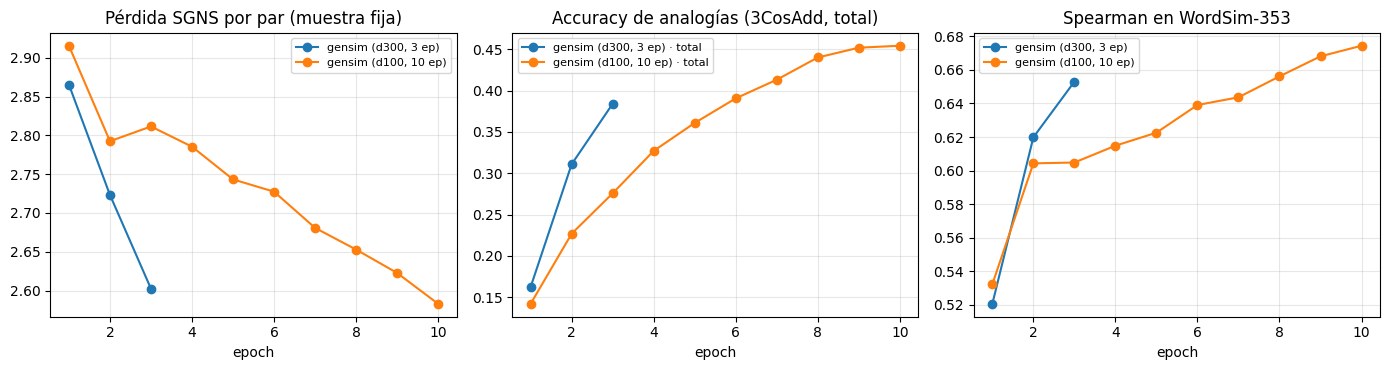

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for run, spec in GENSIM_RUNS.items():
    h = histories[run]
    ax[0].plot(h.epoch, h.loss, "o-", label=spec["label"])
    ax[1].plot(h.epoch, h.acc_total, "o-", label=spec["label"] + " · total")
    ax[2].plot(h.epoch, h.wordsim353, "o-", label=spec["label"])
ax[0].set_title("Pérdida SGNS por par (muestra fija)"); ax[1].set_title("Accuracy de analogías (3CosAdd, total)")
ax[2].set_title("Spearman en WordSim-353")
for a in ax:
    a.set_xlabel("epoch"); a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS / "figs" / "gensim_curvas_por_epoch.png", dpi=130); plt.show()

In [6]:
rows = []
for run, spec in GENSIM_RUNS.items():
    last = str(spec["cfg"]["epochs"])
    for w, lst in neighbors_hist[run][last].items():
        rows.append(dict(modelo=spec["label"], palabra=w, vecinos=", ".join(f"{n} ({s:.2f})" for n, s in lst)))
pd.DataFrame(rows).set_index(["modelo", "palabra"])

vecinos
modelo               palabra                                                    
gensim (d300, 3 ep)  king      cnut (0.59), æthelwulf (0.58), 1135 (0.57), ea...
                     france    italy (0.72), spain (0.72), belgium (0.71), ne...
                     computer  computers (0.71), spacewar (0.67), software (0...
                     good      excellent (0.61), bad (0.60), decent (0.57), l...
                     january   february (0.91), december (0.91), march (0.90)...
                     run       running (0.63), ran (0.60), runs (0.55), insid...
gensim (d100, 10 ep) king      uncrowned (0.79), ealdred (0.77), boleslaus (0...
                     france    spain (0.85), italy (0.83), belgium (0.80), po...
                     computer  computers (0.81), desktop (0.78), programmable...
                     good      bad (0.78), excellent (0.74), enviable (0.70),...
                     january   february (0.98), december (0.98), november (0....
                     run       running (0.73), 2-run (0.69), ran (0.67), nint...

## 4.B.3 GloVe preentrenado

`glove-wiki-gigaword-100` se usa sin ningún entrenamiento adicional: vectores de 100 dimensiones entrenados por Pennington et al. (2014). Es un modelo basado en la matriz de co-ocurrencia global, a diferencia de Word2Vec que es predictivo.

La tabla comparativa de la sección 7 pide, para GloVe, el tiempo de entrenamiento y el hardware **reportados por sus autores**. Se verificaron en el artículo original (Pennington, Socher y Manning, 2014, *GloVe: Global Vectors for Word Representation*, EMNLP; §4.2 y §4.6):

| Dato | Valor reportado |
|---|---|
| Corpus de `glove-wiki-gigaword-100` | Wikipedia 2014 (1.6 B tokens) + Gigaword 5 (4.3 B tokens) = **6 B tokens**, vocabulario de los 400,000 tokens más frecuentes, en minúsculas |
| Construcción de la matriz de co-ocurrencia X | **≈ 85 min** con **1 hilo** de una máquina **dual Intel Xeon E5-2658 a 2.1 GHz** (ventana simétrica de 10 palabras, vocabulario de 400,000, corpus de 6 B) |
| Entrenamiento | AdaGrad, tasa inicial 0.05, `x_max = 100`, α = 3/4; **50 iteraciones** para vectores de menos de 300 dimensiones (100 para ≥ 300) |
| Tiempo por iteración | **14 min** con vectores de **300 dimensiones** usando los **32 núcleos** de esa máquina. **No reportan el tiempo para 100 dimensiones.** |
| GPU | No se menciona uso de GPU |

Para 100 dimensiones el tiempo total no está publicado. Como **estimación nuestra (no es un dato de los autores)**: si el costo por iteración no superara el de 300 dimensiones, el entrenamiento tomaría como máximo ≈ 50 × 14 min ≈ 11.7 h, más los ≈ 85 min de la matriz.

In [7]:
glove_kv = api.load("glove-wiki-gigaword-100")
glove_space = EV.EmbeddingSpace.from_keyed_vectors(glove_kv, name="GloVe-100")
print(f"GloVe: {len(glove_space):,} palabras x {glove_space.dim} dimensiones")

glove_reportado = dict(
    modelo="GloVe-100 (glove-wiki-gigaword-100), preentrenado por Pennington, Socher y Manning (2014); usado sin entrenamiento adicional",
    fuente="Pennington et al. (2014), GloVe: Global Vectors for Word Representation, EMNLP; secciones 4.2 y 4.6 (https://nlp.stanford.edu/pubs/glove.pdf)",
    corpus="Wikipedia 2014 (1.6 B tokens) + Gigaword 5 (4.3 B tokens)", tokens_corpus=6_000_000_000, vocabulario=400_000, dim=100,
    ventana="simétrica de 10 palabras (ponderación 1/d)",
    entrenamiento=dict(optimizador="AdaGrad", lr_inicial=0.05, x_max=100, alpha=0.75, iteraciones_dim_menor_300=50, iteraciones_dim_mayor_igual_300=100),
    hardware_reportado="máquina dual Intel Xeon E5-2658 a 2.1 GHz (32 núcleos); sin GPU mencionada",
    tiempo_reportado=dict(matriz_cooccurrencia_min=85, matriz_cooccurrencia_hilos=1,
                          iteracion_d300_min=14, iteracion_d300_nucleos=32,
                          total_d100="no reportado"),
    estimacion_propia_cota_superior_h=dict(valor=round(50 * 14 / 60 + 85 / 60, 1),
                                           nota="NO es un dato de los autores: 50 iteraciones x 14 min (costo de d=300) + 85 min de matriz"),
    memoria_gpu="no aplica / no reportada",
)
json.dump(glove_reportado, open(RESULTS / "glove_reportado.json", "w"), indent=1, ensure_ascii=False)
print("Guardado en", RESULTS / "glove_reportado.json")

common = set(glove_space.itos) & set(spaces["gensim_d300_e3"].itos)
print(f"Palabras en común con el vocabulario de gensim/SGNS: {len(common):,} "
      f"({100*len(common)/len(spaces['gensim_d300_e3']):.1f}% del vocabulario propio, {100*len(common)/len(glove_space):.1f}% del de GloVe)")

GloVe: 400,000 palabras x 100 dimensiones
Guardado en results/glove_reportado.json
Palabras en común con el vocabulario de gensim/SGNS: 99,473 (90.7% del vocabulario propio, 24.9% del de GloVe)


## 4.B.4 Evaluación de los conjuntos

In [8]:
wordsim = EV.load_word_pairs("wordsim353.tsv")
questions = EV.load_analogies()

rows = []
for space in [spaces["gensim_d300_e3"], spaces["gensim_d100_e10"], glove_space]:
    an = EV.evaluate_analogies(space, questions, restrict_vocab=30000)
    ws = EV.word_similarity(space, wordsim)
    rows.append({"modelo": space.name, "vocab": len(space), "dim": space.dim,
                 "cobertura analogías": an["coverage"],
                 "sem (3CosAdd)": an["add"]["semantic"], "sin (3CosAdd)": an["add"]["syntactic"], "total (3CosAdd)": an["add"]["total"],
                 "total (3CosMul)": an["mul"]["total"],
                 "WordSim-353 (Spearman)": ws["spearman"], "pares WS usados": ws["n_used"]})
pd.DataFrame(rows).set_index("modelo").T

modelo,"gensim (d300, 3 ep)","gensim (d100, 10 ep)",GloVe-100
vocab,109644.0000,109644.0000,400000.0000
dim,300.0000,100.0000,100.0000
cobertura analogías,0.6055,0.6055,0.7612
sem (3CosAdd),0.2371,0.3891,0.6554
sin (3CosAdd),0.4475,0.4823,0.6545
total (3CosAdd),0.3840,0.4542,0.6549
total (3CosMul),0.3842,0.4262,0.6347
WordSim-353 (Spearman),0.6530,0.6744,0.5327
pares WS usados,353.0000,353.0000,353.0000


In [9]:
nb_s = {s.name: EV.neighbors(s, EV.CONTROL_WORDS, k=5) for s in [spaces["gensim_d300_e3"], spaces["gensim_d100_e10"], glove_space]}
fmt = lambda lst: ", ".join(n for n, _ in lst) if lst else "(fuera de vocabulario)"
pd.DataFrame({n: {w: fmt(nb[w]) for w in EV.CONTROL_WORDS} for n, nb in nb_s.items()})

,"gensim (d300, 3 ep)","gensim (d100, 10 ep)",GloVe-100
king,"cnut, æthelwulf, 1135, eadberht, æthelred","uncrowned, ealdred, boleslaus, harefoot, 1329","prince, queen, son, brother, monarch"
france,"italy, spain, belgium, netherlands, portugal","spain, italy, belgium, portugal, netherlands","belgium, french, britain, spain, paris"
computer,"computers, spacewar, software, mainframe, pdp-1","computers, desktop, programmable, software, pdp-1","computers, software, technology, pc, hardware"
good,"excellent, bad, decent, luck, clever","bad, excellent, enviable, luck, perfect","better, sure, really, kind, very"
january,"february, december, march, july, april","february, december, november, june, march","december, october, february, november, september"
run,"running, ran, runs, inside-the-park, unearned","running, 2-run, ran, ninth-inning, inside-the-...","running, runs, ran, out, go"
